# Imports


In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import date as date
import yfinance as yf
import re
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# Data Management

In [58]:
# Data extraction
start_date = '2019-09-18'
end_date = date.today()
symbol = 'HBAR-USD'
data = yf.download(symbol, start_date, end_date)
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD
Date,,,,,
2019-09-18,0.086921,0.100272,0.080045,0.090519,14772274
2019-09-19,0.057924,0.087721,0.054469,0.087702,27324784
2019-09-20,0.052490,0.059061,0.047800,0.058087,15814443
2019-09-21,0.048021,0.055408,0.045456,0.052402,13144171
2019-09-22,0.039735,0.048237,0.038757,0.048065,10549578
...,...,...,...,...,...
2025-03-13,0.189250,0.202045,0.184279,0.200960,418932757
2025-03-14,0.191889,0.198503,0.187881,0.189250,309365663


In [59]:
print(data)

Price          Close      High       Low      Open     Volume
Ticker      HBAR-USD  HBAR-USD  HBAR-USD  HBAR-USD   HBAR-USD
Date                                                         
2019-09-18  0.086921  0.100272  0.080045  0.090519   14772274
2019-09-19  0.057924  0.087721  0.054469  0.087702   27324784
2019-09-20  0.052490  0.059061  0.047800  0.058087   15814443
2019-09-21  0.048021  0.055408  0.045456  0.052402   13144171
2019-09-22  0.039735  0.048237  0.038757  0.048065   10549578
...              ...       ...       ...       ...        ...
2025-03-13  0.189250  0.202045  0.184279  0.200960  418932757
2025-03-14  0.191889  0.198503  0.187881  0.189250  309365663
2025-03-15  0.192706  0.197011  0.190460  0.191885  223717313
2025-03-16  0.185202  0.194836  0.182333  0.192705  271502752
2025-03-17  0.191654  0.195641  0.184834  0.185198  289292129

[2008 rows x 5 columns]


In [60]:
data.head(10)

Price,Close,High,Low,Open,Volume
Ticker,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD
Date,,,,,
2019-09-18,0.086921,0.100272,0.080045,0.090519,14772274
2019-09-19,0.057924,0.087721,0.054469,0.087702,27324784
2019-09-20,0.052490,0.059061,0.047800,0.058087,15814443
2019-09-21,0.048021,0.055408,0.045456,0.052402,13144171
2019-09-22,0.039735,0.048237,0.038757,0.048065,10549578
2019-09-23,0.037645,0.039803,0.035488,0.039739,11214860
2019-09-24,0.029641,0.043997,0.029084,0.037689,12197101
2019-09-25,0.030202,0.031111,0.025871,0.029515,8906428


In [61]:
data.tail(10)

Price,Close,High,Low,Open,Volume
Ticker,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD
Date,,,,,
2025-03-08,0.226643,0.235342,0.222927,0.232624,268708260
2025-03-09,0.199269,0.230828,0.198443,0.226653,362384007
2025-03-10,0.189435,0.217289,0.188491,0.199239,486936638
2025-03-11,0.195807,0.203500,0.180726,0.189429,633052141
2025-03-12,0.200960,0.214328,0.193305,0.195807,605417094
2025-03-13,0.189250,0.202045,0.184279,0.200960,418932757
2025-03-14,0.191889,0.198503,0.187881,0.189250,309365663
2025-03-15,0.192706,0.197011,0.190460,0.191885,223717313


In [62]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD,HBAR-USD
count,2008.000000,2008.000000,2008.000000,2008.000000,2.008000e+03
mean,0.115571,0.121145,0.109949,0.115566,1.433483e+08
std,0.103249,0.109544,0.097283,0.103311,3.487073e+08
min,0.010080,0.010667,0.010012,0.010054,4.019320e+05
25%,0.046689,0.048221,0.045390,0.046691,2.052982e+07
50%,0.064723,0.066918,0.062363,0.064709,4.698076e+07
75%,0.178509,0.186428,0.168462,0.178573,1.189548e+08
max,0.505923,0.570146,0.462120,0.505475,6.950736e+09


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2008 entries, 2019-09-18 to 2025-03-17
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, HBAR-USD)   2008 non-null   float64
 1   (High, HBAR-USD)    2008 non-null   float64
 2   (Low, HBAR-USD)     2008 non-null   float64
 3   (Open, HBAR-USD)    2008 non-null   float64
 4   (Volume, HBAR-USD)  2008 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 94.1 KB


In [64]:
def unify_column_names(name: str) -> str:
    """Converts column names to lowercase, replaces spaces/hyphens with underscores, and handles MultiIndex."""
    return (
        tuple(re.sub(r"[-\s]+", "_", str(n).lower()) for n in name)
        if isinstance(name, tuple)
        else re.sub(r"[-\s]+", "_", str(name).lower())
    )


# Apply transformation to column names
data.columns = data.columns.map(unify_column_names)

In [65]:
print(f"Unified columns names: \n{data.columns}")

Unified columns names: 
MultiIndex([( 'close', 'hbar_usd'),
            (  'high', 'hbar_usd'),
            (   'low', 'hbar_usd'),
            (  'open', 'hbar_usd'),
            ('volume', 'hbar_usd')],
           names=['Price', 'Ticker'])


In [66]:
# Add returns and range
df = data.copy()
df["returns"] = df["close"].pct_change()
df["range"] = (df["high"] / df["low"]) - 1

In [67]:
df.head(10)

Price,close,high,low,open,volume,returns,range
Ticker,hbar_usd,hbar_usd,hbar_usd,hbar_usd,hbar_usd,,
Date,,,,,,,
2019-09-18,0.086921,0.100272,0.080045,0.090519,14772274,NaN,0.252695
2019-09-19,0.057924,0.087721,0.054469,0.087702,27324784,-0.333602,0.610476
2019-09-20,0.052490,0.059061,0.047800,0.058087,15814443,-0.093813,0.235586
2019-09-21,0.048021,0.055408,0.045456,0.052402,13144171,-0.085140,0.218937
2019-09-22,0.039735,0.048237,0.038757,0.048065,10549578,-0.172549,0.244601
2019-09-23,0.037645,0.039803,0.035488,0.039739,11214860,-0.052598,0.121590
2019-09-24,0.029641,0.043997,0.029084,0.037689,12197101,-0.212618,0.512756
2019-09-25,0.030202,0.031111,0.025871,0.029515,8906428,0.018926,0.202543


In [68]:
# Determine the total of NA values and drop them
na_count = df.isna().sum().sum()
if na_count > 0:
    print(f"Dropping {na_count} NA value(s)")
    df.dropna(inplace=True)

Dropping 1 NA value(s)


In [69]:
# Structure data
X_train = df[["returns", "range"]]
X_train.head(10)

Price,returns,range
Ticker,,
Date,,
2019-09-19,-0.333602,0.610476
2019-09-20,-0.093813,0.235586
2019-09-21,-0.085140,0.218937
2019-09-22,-0.172549,0.244601
2019-09-23,-0.052598,0.121590
2019-09-24,-0.212618,0.512756
2019-09-25,0.018926,0.202543
2019-09-26,-0.040924,0.136129


# HMM Learning

In [70]:
# Fit model
np.random.seed(42)
hmm_model = GaussianHMM(n_components=4, covariance_type="full", n_iter=1000, random_state=42).fit(X_train)
hmm_model_score = hmm_model.score(X_train)
print(f"HMM score: {hmm_model_score}")

HMM score: 7331.3109000505165


In [71]:
# Check results
hidden_states = hmm_model.predict(X_train)
print(hidden_states[:100])
print(len(hidden_states))

[3 3 3 3 3 3 3 3 3 1 3 3 1 2 1 1 1 2 0 0 0 0 2 0 2 1 1 1 2 2 0 0 0 2 2 1 1
 1 1 1 1 2 0 0 0 1 1 1 2 2 1 1 2 2 0 0 2 2 0 0 2 1 2 2 2 1 2 1 1 1 1 1 2 1
 2 0 2 1 1 1 1 2 2 1 2 1 1 2 2 2 1 2 1 2 1 3 2 2 0 0]
2007


In [72]:
dir(hmm_model)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_accumulate_sufficient_statistics',
 '_accumulate_sufficient_statistics_log',
 '_accumulate_sufficient_statistics_scaling',
 '_build_request_for_signature',
 '_check',
 '_check_and_set_n_features',
 '_check_feature_names',
 '_check_n_features',
 '_check_sum_1',
 '_compute_likelihood',
 '_compute_log_likelihood',
 '_compute_lower_bound',
 '_compute_posteriors_log',
 '_compute_posteriors_scaling',
 '_covars_',
 '_decode_map',
 '_decode_viterbi',
 '_do_estep',
 '_do_mstep',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator

In [73]:
# Regime state means for each feature
hmm_model.means_

array([[ 0.00389258,  0.04165445],
       [ 0.03585339,  0.09908228],
       [-0.04672542,  0.08964938],
       [ 0.03656499,  0.28584418]])

In [74]:
# Regime state covariances
hmm_model.covars_

array([[[ 4.38274634e-04,  7.61700022e-05],
        [ 7.61700022e-05,  2.42458257e-04]],

       [[ 1.68028503e-03,  8.07664339e-04],
        [ 8.07664339e-04,  1.34670424e-03]],

       [[ 8.42880508e-04, -7.54611799e-04],
        [-7.54611799e-04,  1.32886900e-03]],

       [[ 3.61582989e-02,  1.48129163e-02],
        [ 1.48129163e-02,  3.23429441e-02]]])

# Data Visualization

In [75]:
# Structure prices for plotting

# Initialize lists for each hidden state
labels_0 = []
labels_1 = []
labels_2 = []
labels_3 = []

# Convert close prices to NUmPy array
prices = df["close"].values.astype(float)

# Verify dimensions
print(f"Correct number of rows: {len(prices) == len(hidden_states)}")

Correct number of rows: True


In [76]:
# Assign prices to respective state labels, filling others with NaN
for i, s in enumerate(hidden_states):
    price_value = prices[i].item()

    labels_0.append(price_value if s == 0 else np.nan)
    labels_1.append(price_value if s == 1 else np.nan)
    labels_2.append(price_value if s == 2 else np.nan)
    labels_3.append(price_value if s == 3 else np.nan)

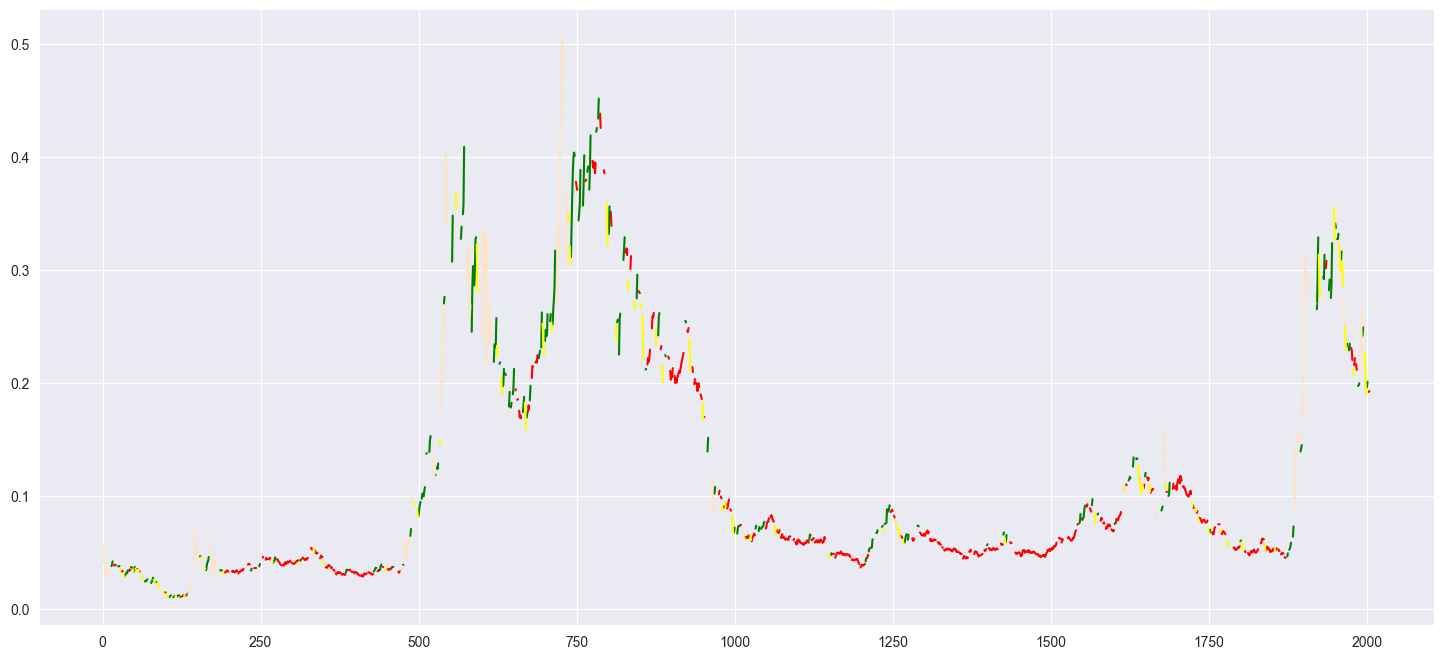

In [77]:
# Plot chart
fig = plt.figure(figsize=(18, 8))
plt.plot(labels_0, color="red")
plt.plot(labels_1, color="green")
plt.plot(labels_2, color="yellow")
plt.plot(labels_3, color="bisque")
plt.show()